<a href="https://colab.research.google.com/github/ethanlam101/151B_SP26_Competition_deep_learners/blob/main/starter_code_cse151b_comp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSE 151B Competition — Starter Notebook

Welcome to the **CSE 151B Spring 2026 Math Reasoning Competition**!  
This notebook walks you through the full pipeline end-to-end:

1. Setting up the Python environment with `uv`
2. Loading the competition dataset
3. Running inference with **Qwen3-4B-Thinking** via vLLM (INT8 quantized)
4. Scoring responses against ground-truth answers
5. Saving results to JSONL for submission

The public dataset (`public.jsonl`) contains questions **with** answers so you can measure accuracy locally.  
The private test set used for the leaderboard does **not** include answers — for that, skip evaluation and submit the raw responses.

## 1. Environment Setup

We use [`uv`](https://github.com/astral-sh/uv) for fast, reproducible package management.

The steps below:
1. Install `uv` into `~/.local/bin`
2. Create a virtual environment at `.venv/`
3. Install all required packages (This might take a while)

> **After running this cell, restart the kernel** so that the newly installed packages (especially `vllm` and `transformers`) are picked up by the current Python session.

### Comment Out the cell below after first installation.

In [ ]:
# lowk dont use

# # Install uv
# !wget -qO- https://astral.sh/uv/install.sh | sh

# # Create a virtual environment
# !uv venv .venv --seed

# # Install dependencies — this is fast thanks to uv's parallel resolver
# !.venv/bin/python -m pip install sympy numpy transformers vllm tqdm bitsandbytes antlr4-python3-runtime==4.11.1 ipykernel jupyter

# # Install Jupyter Kernel
# !.venv/bin/python -m ipykernel install --user --name cse151b --display-name "Python (cse151b)"

# print("Done. Restart the kernel before proceeding.")
# print("Selection process: on top right, click on current kernel '(ususally named python)' -> 'select another kernel' -> 'Jupyter Kernel' -> 'Python (cse151b)'.")

### Run the cell below every time to activate the installed environment.

In [ ]:
# # activate venv after installation. This needs to be run everytime.
# !source ./.venv/bin/activate

## 2. Imports & Configuration

All key settings are collected in one place.  
- `DATA_PATH` — public dataset with ground-truth answers (use this to measure accuracy)
- `OUTPUT_PATH` — where per-question results will be written
- `GPU_ID` — which GPU to use (update if your machine has a different device index)
- `MAX_TOKENS` — maximum tokens the model may generate per response

In [11]:
import subprocess, sys

# Install exact versions known to work together on Colab T4
!pip install \
    vllm==0.8.5 \
    transformers==4.51.3 \
    protobuf==3.20.3 \
    antlr4-python3-runtime==4.11.1

  # i had to change the dependencies a lil to get mine working, below is the OG ones - ethan
  #   vllm==0.8.5 \
  #   transformers==4.51.3 \
  #   protobuf==5.29.6 \
  #   triton==3.0.0 \
  #   antlr4-python3-runtime==4.11.1

print("Done! Restart runtime before continuing.")

  Using cached vllm-0.8.5-cp38-abi3-manylinux1_x86_64.whl.metadata (14 kB)
  Using cached transformers-4.51.3-py3-none-any.whl.metadata (38 kB)
  Using cached antlr4_python3_runtime-4.11.1-py3-none-any.whl.metadata (291 bytes)
  Using cached blake3-1.0.8-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.6 kB)
  Using cached prometheus_fastapi_instrumentator-7.1.0-py3-none-any.whl.metadata (13 kB)
  Using cached lm_format_enforcer-0.10.12-py3-none-any.whl.metadata (17 kB)
  Using cached llguidance-0.7.30-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (10 kB)
  Using cached outlines-0.1.11-py3-none-any.whl.metadata (17 kB)
  Using cached lark-1.2.2-py3-none-any.whl.metadata (1.8 kB)
  Using cached xgrammar-0.1.18-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.6 kB)
  Using cached partial_json_parser-0.2.1.1.post7-py3-none-any.whl.metadata (6.1 kB)
  Using cached msgspec-0.21.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_

Done! Restart runtime before continuing.


In [3]:
!pip install --force-reinstall google-api-core # dependency version was still off even after restarting session so i need to do this in order for it to run - ethan

  Using cached google_api_core-2.30.3-py3-none-any.whl.metadata (3.1 kB)
  Using cached googleapis_common_protos-1.74.0-py3-none-any.whl.metadata (9.2 kB)
  Using cached protobuf-7.34.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
  Using cached proto_plus-1.27.2-py3-none-any.whl.metadata (2.2 kB)
  Using cached google_auth-2.50.0-py3-none-any.whl.metadata (6.2 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached cryptography-47.0.0-cp311-abi3-manylinux_2_34_x86_64.whl.metadata (4.5 kB)
  Using cached charset_normalizer-3.4.7-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached idna-3.13-py3-none-any.whl.metadata (8.0 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.4.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached cffi-2.0.0-cp312-cp312-manylinux2014_x86_64.many

In [1]:
import google.protobuf
import os
print(f"Version: {google.protobuf.__version__}")
print(f"Path: {os.path.dirname(google.protobuf.__file__)}")

Version: 7.34.1
Path: /usr/local/lib/python3.12/dist-packages/google/protobuf


In [1]:
import json
import os

# ── Configuration ─────────────────────────────────────────────────────────────
MODEL_ID    = "Qwen/Qwen3-4B-Thinking-2507"
GPU_ID      = "0" #"1"                    # CUDA_VISIBLE_DEVICES
# DATA_PATH   = "data/public.jsonl"
DATA_PATH   = "public.jsonl"

OUTPUT_PATH = "results/starter_results.jsonl"
# MAX_TOKENS  = 32768
MAX_TOKENS = 4096

os.environ["CUDA_VISIBLE_DEVICES"] = GPU_ID

import re
import sys
from pathlib import Path
from typing import Optional

from transformers import AutoTokenizer
from vllm import LLM, SamplingParams
from tqdm import tqdm

INFO 05-04 01:44:05 [__init__.py:239] Automatically detected platform cuda.


## 3. Load the Dataset

The dataset is stored as newline-delimited JSON (`.jsonl`). Each line is one question with the following fields:

| Field | Description |
|---|---|
| `id` | Unique question identifier |
| `question` | Problem statement |
| `options` | List of answer choices — present for **MCQ**, absent for **free-form** |
| `answer` | Ground-truth answer (letter for MCQ, value/list for free-form) |

In [2]:
import pandas as pd

In [3]:
!wget https://raw.githubusercontent.com/ethanlam101/151B_SP26_Competition_deep_learners/refs/heads/main/data/public.jsonl

--2026-05-04 01:44:18--  https://raw.githubusercontent.com/ethanlam101/151B_SP26_Competition_deep_learners/refs/heads/main/data/public.jsonl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 668383 (653K) [text/plain]
Saving to: ‘public.jsonl.5’

public.jsonl.5      100%[===================>] 652.72K  --.-KB/s    in 0.004s  

2026-05-04 01:44:18 (174 MB/s) - ‘public.jsonl.5’ saved [668383/668383]



In [4]:
df = pd.read_json("public.jsonl", lines=True)
df

,question,answer,id,options
0,Find the sum of the first $325$ positive even ...,[325*(1+325)],0,NaN
1,$int_{-infty}^{+infty} frac{a^{3/2}}{s^2+a^2} ...,F,1,"[$0$, $frac{1}{a}$, $frac{3}{a}$, $frac{1}{2a^..."
2,A roasted turkey is taken from an oven when it...,"[143.224229233795, 2.32624773420025]",2,NaN
3,Reduce the fraction ${\frac{25}{40}}$. [ANS],[5/8],3,NaN
4,"Given $u(x, y) = x^3 + 6x^2y - 3xy^2 - 2y^3$, ...",C,4,"[$$\n( 6+4 \mathrm{i} ) z^{5}\n$$, $$\n( 4-5 \..."
...,...,...,...,...
1121,Give the constant term and the coefficient of ...,"[0, 10+r]",1121,NaN
1122,Find all angles $x$ (in radians) that satisfy ...,[2*pi/3+k*pi],1122,NaN
1123,Divide the integer by the fraction:\n${15 \div...,[24],1123,NaN
1124,(a) What is the average rate of change of $g(x...,"[5, increasing]",1124,NaN


In [5]:
data = [json.loads(line) for line in open(DATA_PATH)]

n_mcq  = sum(bool(d.get("options")) for d in data)
n_free = sum(not d.get("options")   for d in data)
print(f"Loaded {len(data)} questions  ({n_mcq} MCQ, {n_free} free-form)")

# Preview one MCQ and one free-form item
mcq_sample  = next(d for d in data if d.get("options"))
free_sample = next(d for d in data if not d.get("options"))

print("\n── MCQ sample ──")
print(json.dumps(mcq_sample, indent=2))
print("\n── Free-form sample ──")
print(json.dumps(free_sample, indent=2))

Loaded 1126 questions  (375 MCQ, 751 free-form)

── MCQ sample ──
{
  "question": "$int_{-infty}^{+infty} frac{a^{3/2}}{s^2+a^2} ds = $",
  "options": [
    "$0$",
    "$frac{1}{a}$",
    "$frac{3}{a}$",
    "$frac{1}{2a^2}$",
    "$frac{1}{2a}$",
    "$frac{2}{a}$",
    "$2a$",
    "$frac{3}{2a}$",
    "$frac{3}{2a^2}$",
    "$frac{1}{a^2}$"
  ],
  "answer": "F",
  "id": 1
}

── Free-form sample ──
{
  "question": "Find the sum of the first $325$ positive even whole numbers. Sum: [ANS]",
  "answer": [
    "325*(1+325)"
  ],
  "id": 0
}


## 4. Prompt Construction

We use two system prompts depending on the question type:

- **MCQ** — the model must select the best answer letter and wrap it in `\boxed{}`
- **Free-form** — the model solves step-by-step and puts the final answer in `\boxed{}`

`build_prompt()` returns the appropriate `(system, user)` pair for each item.

In [6]:
# SYSTEM_PROMPT_MATH = (
#     "You are an expert mathematician. Solve the problem step-by-step. "
#     "Put your final answer inside \\boxed{}. "
#     "If the problem has multiple sub-answers, separate them by commas inside a single \\boxed{}, "
#     "e.g. \\boxed{3, 7}."
# )

# SYSTEM_PROMPT_MCQ = (
#     "You are an expert mathematician. "
#     "Read the problem and the answer choices below, then select the single best answer. "
#     "Output ONLY the letter of your chosen option inside \\boxed{}, e.g. \\boxed{C}."
# )

SYSTEM_PROMPT_MATH = (
    "You are an expert mathematician. Solve the problem using maximum 3 clear steps. These problems are not meant to trick you."
    "Do not provide a narrative; provide only the necessary calculations. Limit your answer to 300 words."
    "Final answer in \\boxed{}. For multiple answers: \\boxed{3, 7}."
)

SYSTEM_PROMPT_MCQ = (
    "You are an expert mathematician. "
    "Select the best answer. Output ONLY \\boxed{LETTER}, e.g. \\boxed{C}. "
    "No explanation needed."
)


def build_prompt(question: str, options: Optional[list]) -> tuple[str, str]:
    """Return (system_prompt, user_prompt) for a question."""
    if options:
        labels    = [chr(65 + i) for i in range(len(options))]
        opts_text = "\n".join(f"{lbl}. {opt.strip()}" for lbl, opt in zip(labels, options))
        return SYSTEM_PROMPT_MCQ, f"{question}\n\nOptions:\n{opts_text}"
    return SYSTEM_PROMPT_MATH, question


# Verify with samples
for label, item in [("MCQ", mcq_sample), ("Free-form", free_sample)]:
    sys_p, usr_p = build_prompt(item["question"], item.get("options"))
    print(f"── {label} user prompt (first 200 chars) ──")
    print(usr_p[:200], "...\n")

── MCQ user prompt (first 200 chars) ──
$int_{-infty}^{+infty} frac{a^{3/2}}{s^2+a^2} ds = $

Options:
A. $0$
B. $frac{1}{a}$
C. $frac{3}{a}$
D. $frac{1}{2a^2}$
E. $frac{1}{2a}$
F. $frac{2}{a}$
G. $2a$
H. $frac{3}{2a}$
I. $frac{3}{2a^2}$
J. ...

── Free-form user prompt (first 200 chars) ──
Find the sum of the first $325$ positive even whole numbers. Sum: [ANS] ...



## 5. Load Model with vLLM (for general case, vLLM is faster)

We load **Qwen3-4B-Thinking-2507** with **INT8 quantization** via BitsAndBytes.  
Setting `load_format="bitsandbytes"` tells vLLM to apply on-the-fly INT8 weight quantization, roughly halving GPU memory usage compared to BF16.

Key parameters:
- `gpu_memory_utilization` — fraction of GPU VRAM reserved for the model and KV cache
- `max_model_len` — maximum sequence length (prompt + generation)
- `max_num_seqs` — maximum number of sequences processed in parallel

In [7]:
# SO THE NEXT CELL WORKS: DO RUNTIME --> CHANGE RUNTIME TYPE --> CHANGE TO 64 GPU

In [8]:
# tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
# tokenizer.pad_token = tokenizer.eos_token

llm = LLM(
    model=MODEL_ID,
    # quantization="bitsandbytes",
    # load_format="bitsandbytes",
    enable_prefix_caching=False,
    gpu_memory_utilization=0.9, #originally 0.50
    max_model_len=5120, #originally 16384
    trust_remote_code=True,
    max_num_seqs=16, #originally 256
    max_num_batched_tokens=32768,
    dtype="half",
)

tokenizer = llm.get_tokenizer()
# tokenizer.pad_token = tokenizer.eos_token

# added different params for mcq vs freeform
sampling_params_mcq = SamplingParams(
    max_tokens=64,        # MCQ just needs \boxed{X}
    temperature=0.3,      # lower temp = more deterministic letter selection
    top_p=0.9,
    top_k=20,
    min_p=0.0,
    repetition_penalty=1.0,
)

# Free-form math needs room to reason
sampling_params_freeform = SamplingParams(
    max_tokens=1024,      # enough for step-by-step without blowing budget
    temperature=0.3,
    top_p=0.95,
    top_k=20,
    min_p=0.0,
    presence_penalty=0.0,
    repetition_penalty=1.0,
)

print("Model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


WARNING 05-04 01:44:20 [config.py:2972] Casting torch.bfloat16 to torch.float16.
INFO 05-04 01:44:38 [config.py:717] This model supports multiple tasks: {'classify', 'reward', 'generate', 'embed', 'score'}. Defaulting to 'generate'.
WARNING 05-04 01:44:38 [arg_utils.py:1658] Compute Capability < 8.0 is not supported by the V1 Engine. Falling back to V0. 
INFO 05-04 01:44:38 [llm_engine.py:240] Initializing a V0 LLM engine (v0.8.5) with config: model='Qwen/Qwen3-4B-Thinking-2507', speculative_config=None, tokenizer='Qwen/Qwen3-4B-Thinking-2507', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.float16, max_seq_len=5120, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='

Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]


INFO 05-04 01:45:15 [loader.py:458] Loading weights took 32.54 seconds
INFO 05-04 01:45:15 [model_runner.py:1140] Model loading took 7.6065 GiB and 33.718734 seconds
INFO 05-04 01:45:30 [worker.py:287] Memory profiling takes 14.15 seconds
INFO 05-04 01:45:30 [worker.py:287] the current vLLM instance can use total_gpu_memory (14.56GiB) x gpu_memory_utilization (0.90) = 13.11GiB
INFO 05-04 01:45:30 [worker.py:287] model weights take 7.61GiB; non_torch_memory takes 0.05GiB; PyTorch activation peak memory takes 2.41GiB; the rest of the memory reserved for KV Cache is 3.04GiB.
INFO 05-04 01:45:31 [executor_base.py:112] # cuda blocks: 1382, # CPU blocks: 1820
INFO 05-04 01:45:31 [executor_base.py:117] Maximum concurrency for 5120 tokens per request: 4.32x
INFO 05-04 01:45:34 [model_runner.py:1450] Capturing cudagraphs for decoding. This may lead to unexpected consequences if the model is not static. To run the model in eager mode, set 'enforce_eager=True' or use '--enforce-eager' in the CLI.

Capturing CUDA graph shapes:   0%|          | 0/5 [00:00<?, ?it/s]

INFO 05-04 01:45:42 [model_runner.py:1592] Graph capturing finished in 8 secs, took 0.08 GiB
INFO 05-04 01:45:42 [llm_engine.py:437] init engine (profile, create kv cache, warmup model) took 26.85 seconds
Model loaded.


## 5. Load Model with Transformers (alternative to vLLM for DataHub)

We load **Qwen3-4B-Thinking-2507** with **INT4 quantization** via BitsAndBytes.  

Key parameters:
- `load_in_4bit` — quantization strategy of INT4

In [9]:
# import torch
# from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# MODEL_ID = "Qwen/Qwen3-4B-Thinking-2507"

# tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
# tokenizer.pad_token = tokenizer.eos_token

# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_compute_dtype=torch.bfloat16,
#     bnb_4bit_use_double_quant=True,
# )

# llm = AutoModelForCausalLM.from_pretrained(
#     MODEL_ID,
#     trust_remote_code=True,
#     quantization_config=bnb_config,
#     device_map="auto",
# )


## 6. Generate Responses

We format every question into a chat-template prompt, then call `llm.generate()` in one batched pass.  
vLLM handles batching and scheduling internally — no manual batching needed.

### Generate with vLLM

In [10]:
import time

responses = []
runtimes  = []

for item in tqdm(data[:10], desc="Generating"): # generates responses for 10 q's
    is_mcq = bool(item.get("options"))
    system, user = build_prompt(item["question"], item.get("options"))

    # /no_think on MCQ to suppress chain-of-thought and save tokens
    user_content = user + ("/no_think" if is_mcq else "")

    prompt_text = tokenizer.apply_chat_template(
        [{"role": "system", "content": system},
         {"role": "user",   "content": user_content}],
        tokenize=False,
        add_generation_prompt=True,
    )

    params = sampling_params_mcq if is_mcq else sampling_params_freeform

    t0 = time.perf_counter()
    output = llm.generate([prompt_text], params)
    elapsed = time.perf_counter() - t0

    response_text = output[0].outputs[0].text.strip()
    token_count   = len(output[0].outputs[0].token_ids)

    responses.append(response_text)
    runtimes.append({
        "id":               item.get("id"),
        "is_mcq":           is_mcq,
        "elapsed_sec":      elapsed,
        "tokens_generated": token_count,
        "tokens_per_sec":   token_count / elapsed if elapsed > 0 else 0,
    })

# Runtime summary
total_time   = sum(r["elapsed_sec"]      for r in runtimes)
total_tokens = sum(r["tokens_generated"] for r in runtimes)
print(f"\nTotal time        : {total_time:.1f}s")
print(f"Total tokens      : {total_tokens:,}")
print(f"Avg per question  : {total_time / len(runtimes):.2f}s")
print(f"Overall tok/sec   : {total_tokens / total_time:.1f}")

# Preview first 3
for i in range(min(3, len(responses))):
    print(f"\n── Response {i} (id={data[i].get('id')}) ──")
    print(responses[i][:400], "..." if len(responses[i]) > 400 else "")

Generating:   0%|          | 0/10 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating:  10%|█         | 1/10 [00:41<06:11, 41.30s/it]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating:  20%|██        | 2/10 [00:43<02:28, 18.57s/it]

...

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating:  90%|█████████ | 9/10 [04:05<00:30, 30.57s/it]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generating: 100%|██████████| 10/10 [04:07<00:00, 24.79s/it]


Total time        : 247.8s
Total tokens      : 6,151
Avg per question  : 24.78s
Overall tok/sec   : 24.8

── Response 0 (id=0) ──
Okay, let's see. I need to find the sum of the first 325 positive even whole numbers. Hmm, first, what's the first positive even whole number? That's 2, right? Then the next one is 4, 6, 8, and so on. So the sequence is 2, 4, 6, 8, ..., up to the 325th term. 

I remember that the sum of the first n even numbers can be calculated using a formula. Let me think. The nth even number is 2n, right? Beca ...

── Response 1 (id=1) ──
Okay, let's try to figure out this integral. The problem is the integral from negative infinity to positive infinity of (a^(3/2)) divided by (s^2 + a^2) ds. Hmm, first, I need to recall how to integrate functions like 1/(s^2 + a 

── Response 2 (id=2) ──
Okay, let's tackle part (a) first. This is a Newton's Law of Cooling problem. Newton's Law states that the rate of change of the temperature of an object is proportional to the differe

### Generate with Transformers (for Datahub)

In [11]:
# # Build prompts for first 5 entries
# prompts = []
# for item in data[:5]:
#     system, user = build_prompt(item["question"], item.get("options"))
#     prompt_text = tokenizer.apply_chat_template(
#         [{"role": "system", "content": system},
#          {"role": "user",   "content": user}],
#         tokenize=False,
#         add_generation_prompt=True,
#     )
#     prompts.append(prompt_text)

# # Tokenize (padded batch)
# print(f"Generating responses for {len(prompts)} questions...")
# inputs = tokenizer(
#     prompts,
#     return_tensors="pt",
#     padding=True,
#     truncation=True,
#     max_length=16384,
# ).to(llm.device)

# # Generate
# with torch.no_grad():
#     output_ids = llm.generate(
#         **inputs,
#         max_new_tokens=MAX_TOKENS,
#         temperature=0.6,
#         top_p=0.95,
#         top_k=20,
#         repetition_penalty=1.0,
#         do_sample=True,
#     )

# # Decode only the new tokens (strip the prompt)
# responses = []
# for i, out in enumerate(output_ids):
#     new_tokens = out[inputs["input_ids"].shape[1]:]
#     responses.append(tokenizer.decode(new_tokens, skip_special_tokens=True).strip())

# # Preview first 3
# for i in range(min(3, len(responses))):
#     print(f"\n── Response {i} (id={data[i].get('id')}) ──")
#     print(responses[i][:400], "..." if len(responses[i]) > 400 else "")

## 7. Score Responses

Scoring differs by question type:

- **MCQ**: extract the predicted letter from `\boxed{}` and compare to the gold letter (exact match).
- **Free-form**: use `Judger.auto_judge()` which handles symbolic and numeric equivalence.

Each result record contains `{id, is_mcq, gold, response, correct}`.

In [12]:
!wget https://raw.githubusercontent.com/ethanlam101/151B_SP26_Competition_deep_learners/refs/heads/main/judger.py

--2026-05-04 01:49:50--  https://raw.githubusercontent.com/ethanlam101/151B_SP26_Competition_deep_learners/refs/heads/main/judger.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 38572 (38K) [text/plain]
Saving to: ‘judger.py.6’

judger.py.6         100%[===================>]  37.67K  --.-KB/s    in 0s      

2026-05-04 01:49:51 (115 MB/s) - ‘judger.py.6’ saved [38572/38572]



In [13]:
!wget https://raw.githubusercontent.com/ethanlam101/151B_SP26_Competition_deep_learners/refs/heads/main/utils.py

--2026-05-04 01:49:51--  https://raw.githubusercontent.com/ethanlam101/151B_SP26_Competition_deep_learners/refs/heads/main/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11546 (11K) [text/plain]
Saving to: ‘utils.py.6’

utils.py.6          100%[===================>]  11.28K  --.-KB/s    in 0s      

2026-05-04 01:49:51 (99.2 MB/s) - ‘utils.py.6’ saved [11546/11546]



In [14]:
def extract_letter(text: str) -> str:
    m = re.search(r"\\boxed\{([A-Za-z])\}", text)
    if m:
        return m.group(1).upper()
    matches = re.findall(r"\b([A-Z])\b", text.upper())
    return matches[-1] if matches else ""


def score_mcq(response: str, gold_letter: str) -> bool:
    return extract_letter(response) == gold_letter.strip().upper()


# Load Judger for free-form scoring
sys.path.insert(0, ".")
from judger import Judger
judger = Judger(strict_extract=False)

results = []
for item, response in tqdm(zip(data, responses), total=len(data), desc="Scoring"):
    is_mcq = bool(item.get("options"))
    gold   = item["answer"]

    if is_mcq:
        correct = score_mcq(response, str(gold))
    else:
        gold_list = gold if isinstance(gold, list) else [gold]
        try:
            correct = judger.auto_judge(
                pred=response,
                gold=gold_list,
                options=[[]] * len(gold_list),
            )
        except Exception:
            correct = False

    results.append({
        "id":       item.get("id"),
        "is_mcq":   is_mcq,
        "gold":     gold,
        "response": response,
        "correct":  correct,
    })

print(f"Scoring complete. {len(results)} results.")

Scoring:   1%|          | 10/1126 [00:00<01:01, 18.25it/s]

Scoring complete. 10 results.


In [20]:
data[1]

{'question': '$int_{-infty}^{+infty} frac{a^{3/2}}{s^2+a^2} ds = $',
 'options': ['$0$',
  '$frac{1}{a}$',
  '$frac{3}{a}$',
  '$frac{1}{2a^2}$',
  '$frac{1}{2a}$',
  '$frac{2}{a}$',
  '$2a$',
  '$frac{3}{2a}$',
  '$frac{3}{2a^2}$',
  '$frac{1}{a^2}$'],
 'answer': 'F',
 'id': 1}

In [15]:
results

[{'id': 0,
  'is_mcq': False,
  'gold': ['325*(1+325)'],
  'response': "Okay, let's see. I need to find the sum of the first 325 positive even whole numbers. Hmm, first, what's the first positive even whole number? That's 2, right? Then the next one is 4, 6, 8, and so on. So the sequence is 2, 4, 6, 8, ..., up to the 325th term. \n\nI remember that the sum of the first n even numbers can be calculated using a formula. Let me think. The nth even number is 2n, right? Because the first even number is 2*1=2, the second is 2*2=4, the third is 2*3=6, so yeah, the kth even number is 2k. \n\nSo the sum of the first n even numbers would be the sum from k=1 to k=n of 2k. That's equal to 2 times the sum from k=1 to n of k. And the sum of the first n positive integers is n(n+1)/2. So substituting that in, the sum of the first n even numbers is 2*(n(n+1)/2) = n(n+1). Wait, is that right? Let me check with a small n. Let's take n=2: first two even numbers are 2 and 4, sum is 6. Using the formula n(n

## 8. Summary

Print accuracy broken down by question type.

In [22]:
import numpy as np

mcq_res  = [r for r in results if r["is_mcq"]]
free_res = [r for r in results if not r["is_mcq"]]

def acc(subset):
    return sum(r["correct"] for r in subset) / len(subset) * 100 if subset else 0.0

def full_evaluation(results):
    mcq_res  = [r for r in results if r["is_mcq"]]
    free_res = [r for r in results if not r["is_mcq"]]

    def stats(subset):
        if not subset:
            return {"n": 0, "correct": 0, "accuracy": 0.0, "stderr": 0.0}
        correct = [r["correct"] for r in subset]
        return {
            "n":        len(subset),
            "correct":  sum(correct),
            "accuracy": np.mean(correct) * 100,
            "stderr":   np.std(correct) / np.sqrt(len(correct)) * 100,
        }

    print("=" * 55)
    print("EVALUATION RESULTS")
    print("=" * 55)
    for label, subset in [("MCQ", mcq_res), ("Free-form", free_res), ("Overall", results)]:
        s = stats(subset)
        print(f"  {label:<12}: {s['correct']:4d}/{s['n']:4d}  "
              f"({s['accuracy']:.2f}% ± {s['stderr']:.2f}%)")
    print("=" * 55)

    # Runtime summary per type
    mcq_rt   = [r for r in runtimes if r["is_mcq"]]
    free_rt  = [r for r in runtimes if not r["is_mcq"]]
    for label, rt in [("MCQ", mcq_rt), ("Free-form", free_rt)]:
        if rt:
            times  = [r["elapsed_sec"]      for r in rt]
            tokens = [r["tokens_generated"] for r in rt]
            print(f"\n  {label} Runtime:")
            print(f"    Avg time     : {np.mean(times):.2f}s  (max {max(times):.2f}s)")
            print(f"    Avg tokens   : {np.mean(tokens):.0f}  (max {max(tokens)})")
            print(f"    Avg tok/sec  : {np.mean([r['tokens_per_sec'] for r in rt]):.1f}")

full_evaluation(results)

EVALUATION RESULTS
  MCQ         :    0/   3  (0.00% ± 0.00%)
  Free-form   :    3/   7  (42.86% ± 18.70%)
  Overall     :    3/  10  (30.00% ± 14.49%)

  MCQ Runtime:
    Avg time     : 2.68s  (max 2.73s)
    Avg tokens   : 64  (max 64)
    Avg tok/sec  : 23.9

  Free-form Runtime:
    Avg time     : 34.25s  (max 41.29s)
    Avg tokens   : 851  (max 1024)
    Avg tok/sec  : 24.9


In [23]:
from collections import Counter

def error_analysis(results):
    wrong = [r for r in results if not r["correct"]]

    print(f"\n{'='*55}")
    print(f"ERROR ANALYSIS  ({len(wrong)} wrong / {len(results)} total)")
    print(f"{'='*55}")

    # MCQ: what letters did it predict vs gold?
    mcq_wrong = [r for r in wrong if r["is_mcq"]]
    if mcq_wrong:
        predicted = [extract_letter(r["response"]) for r in mcq_wrong]
        gold      = [str(r["gold"]).upper() for r in mcq_wrong]
        print(f"\nMCQ wrong predictions : {Counter(predicted).most_common()}")
        print(f"MCQ wrong gold answers: {Counter(gold).most_common()}")

    # Free-form: did it at least produce a \boxed{}?
    free_wrong = [r for r in wrong if not r["is_mcq"]]
    no_box = [r for r in free_wrong if not re.search(r"\\boxed\{", r["response"])]
    print(f"\nFree-form wrong with no \\boxed{{}}: {len(no_box)}/{len(free_wrong)}")
    if no_box:
        print("  → Likely a prompt issue; model not following format instructions.")

    # Show 3 wrong examples
    print("\n── Sample wrong answers ──")
    for r in wrong[:3]:
        print(f"  ID {r['id']} | gold={r['gold']}")
        print(f"  Response (first 150 chars): {r['response'][:150]}")
        print()

error_analysis(results)


ERROR ANALYSIS  (7 wrong / 10 total)

MCQ wrong predictions : [('A', 1), ('X', 1), ('S', 1)]
MCQ wrong gold answers: [('F', 1), ('C', 1), ('A', 1)]

Free-form wrong with no \boxed{}: 3/4
  → Likely a prompt issue; model not following format instructions.

── Sample wrong answers ──
  ID 0 | gold=['325*(1+325)']
  Response (first 150 chars): Okay, let's see. I need to find the sum of the first 325 positive even whole numbers. Hmm, first, what's the first positive even whole number? That's 

  ID 1 | gold=F
  Response (first 150 chars): Okay, let's try to figure out this integral. The problem is the integral from negative infinity to positive infinity of (a^(3/2)) divided by (s^2 + a^

  ID 2 | gold=['143.224229233795', '2.32624773420025']
  Response (first 150 chars): Okay, let's tackle part (a) first. This is a Newton's Law of Cooling problem. Newton's Law states that the rate of change of the temperature of an obj



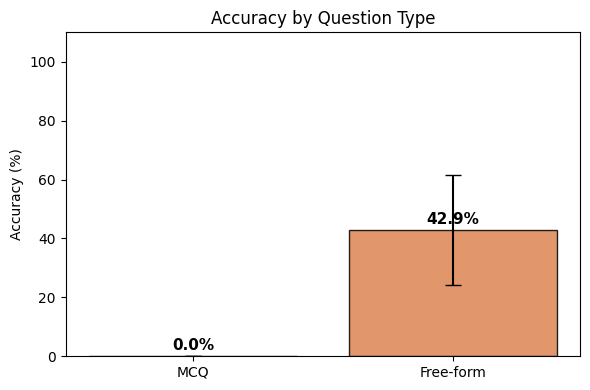

Saved: accuracy_by_type.png


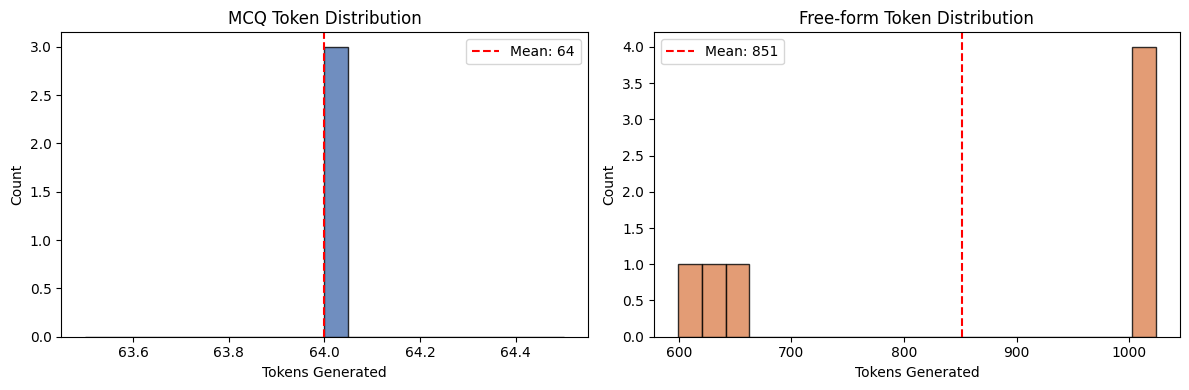

Saved: token_distribution.png


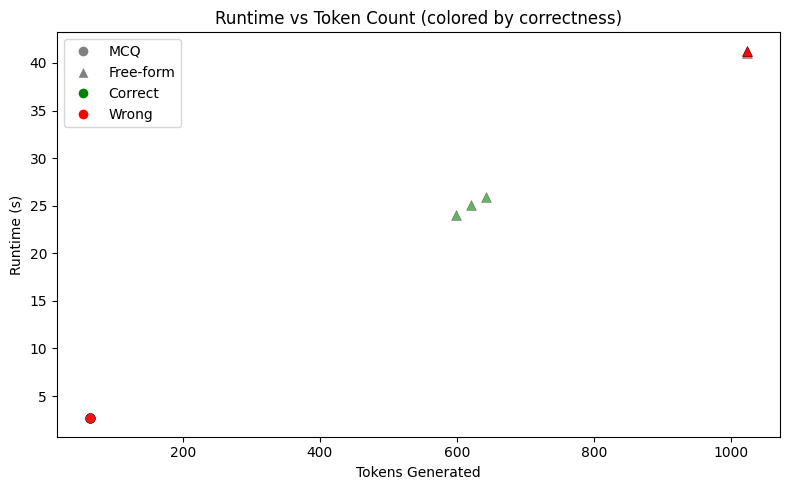

Saved: runtime_scatter.png


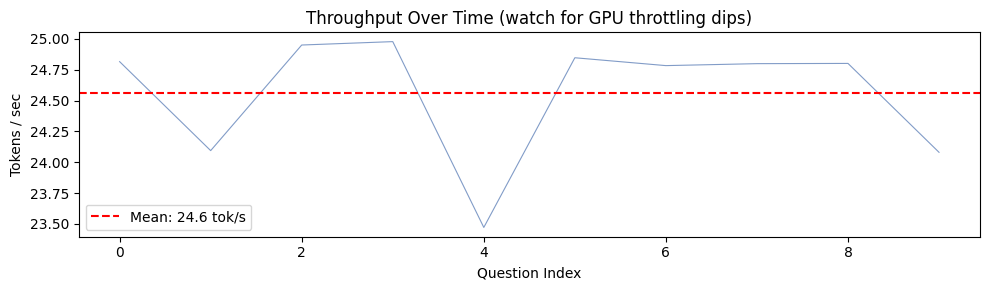

Saved: throughput.png


/tmp/ipykernel_55822/3412652025.py:113: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([correct_tokens, wrong_tokens], labels=["Correct", "Wrong"],


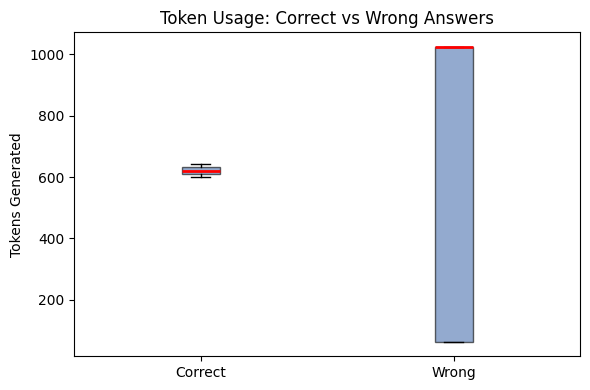

Saved: tokens_correct_vs_wrong.png


In [21]:
import matplotlib.pyplot as plt

def plot_accuracy_by_type(results):
    """Bar chart of accuracy per question type with error bars."""
    categories = {"MCQ": [], "Free-form": []}
    for r in results:
        key = "MCQ" if r["is_mcq"] else "Free-form"
        categories[key].append(r["correct"])

    labels = list(categories.keys())
    accs   = [np.mean(v) * 100 for v in categories.values()]
    errs   = [np.std(v) / np.sqrt(len(v)) * 100 for v in categories.values()]

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(labels, accs, yerr=errs, capsize=6,
                  color=["#4C72B0", "#DD8452"], alpha=0.85, edgecolor="black")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Accuracy by Question Type")
    ax.set_ylim(0, 110)
    for bar, acc_val in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                f"{acc_val:.1f}%", ha="center", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig("accuracy_by_type.png", dpi=150)
    plt.show()
    print("Saved: accuracy_by_type.png")


def plot_token_distribution(runtimes):
    """Histogram of tokens generated, split by question type."""
    mcq_tokens  = [r["tokens_generated"] for r in runtimes if r["is_mcq"]]
    free_tokens = [r["tokens_generated"] for r in runtimes if not r["is_mcq"]]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, tokens, label, color in zip(
        axes,
        [mcq_tokens, free_tokens],
        ["MCQ", "Free-form"],
        ["#4C72B0", "#DD8452"],
    ):
        if not tokens:
            continue
        ax.hist(tokens, bins=20, color=color, alpha=0.8, edgecolor="black")
        ax.axvline(np.mean(tokens), color="red", linestyle="--",
                   label=f"Mean: {np.mean(tokens):.0f}")
        ax.set_xlabel("Tokens Generated")
        ax.set_ylabel("Count")
        ax.set_title(f"{label} Token Distribution")
        ax.legend()

    plt.tight_layout()
    plt.savefig("token_distribution.png", dpi=150)
    plt.show()
    print("Saved: token_distribution.png")


def plot_runtime_scatter(runtimes, results):
    """Scatter: tokens vs runtime, colored by correctness, shaped by question type."""
    correct_map = {r["id"]: r["correct"] for r in results}

    xs      = [r["tokens_generated"] for r in runtimes]
    ys      = [r["elapsed_sec"]      for r in runtimes]
    colors  = ["green" if correct_map.get(r["id"]) else "red"  for r in runtimes]
    markers = ["o"     if r["is_mcq"]               else "^"   for r in runtimes]

    fig, ax = plt.subplots(figsize=(8, 5))
    for x, y, c, m in zip(xs, ys, colors, markers):
        ax.scatter(x, y, color=c, marker=m, alpha=0.6, s=50, edgecolors="black", linewidths=0.3)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",  markersize=8, label="MCQ"),
        Line2D([0], [0], marker="^", color="w", markerfacecolor="gray",  markersize=8, label="Free-form"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="green", markersize=8, label="Correct"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="red",   markersize=8, label="Wrong"),
    ]
    ax.legend(handles=legend_elements, loc="upper left")
    ax.set_xlabel("Tokens Generated")
    ax.set_ylabel("Runtime (s)")
    ax.set_title("Runtime vs Token Count (colored by correctness)")
    plt.tight_layout()
    plt.savefig("runtime_scatter.png", dpi=150)
    plt.show()
    print("Saved: runtime_scatter.png")


def plot_throughput(runtimes):
    """Line chart of tokens/sec over question index — spots GPU throttling."""
    tps = [r["tokens_per_sec"] for r in runtimes]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(tps, alpha=0.7, linewidth=0.8, color="#4C72B0")
    ax.axhline(np.mean(tps), color="red", linestyle="--",
               label=f"Mean: {np.mean(tps):.1f} tok/s")
    ax.set_xlabel("Question Index")
    ax.set_ylabel("Tokens / sec")
    ax.set_title("Throughput Over Time (watch for GPU throttling dips)")
    ax.legend()
    plt.tight_layout()
    plt.savefig("throughput.png", dpi=150)
    plt.show()
    print("Saved: throughput.png")


def plot_correct_vs_tokens(results, runtimes):
    """Box plot: token counts for correct vs wrong answers."""
    runtime_map = {r["id"]: r["tokens_generated"] for r in runtimes}

    correct_tokens = [runtime_map[r["id"]] for r in results if r["correct"]     and r["id"] in runtime_map]
    wrong_tokens   = [runtime_map[r["id"]] for r in results if not r["correct"] and r["id"] in runtime_map]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.boxplot([correct_tokens, wrong_tokens], labels=["Correct", "Wrong"],
               patch_artist=True,
               boxprops=dict(facecolor="#4C72B0", alpha=0.6),
               medianprops=dict(color="red", linewidth=2))
    ax.set_ylabel("Tokens Generated")
    ax.set_title("Token Usage: Correct vs Wrong Answers")
    plt.tight_layout()
    plt.savefig("tokens_correct_vs_wrong.png", dpi=150)
    plt.show()
    print("Saved: tokens_correct_vs_wrong.png")


# Run all visualizations
plot_accuracy_by_type(results)
plot_token_distribution(runtimes)
plot_runtime_scatter(runtimes, results)
plot_throughput(runtimes)
plot_correct_vs_tokens(results, runtimes)

## 9. Save Results

Results are written as newline-delimited JSON.

**With evaluation** (public set — you have ground-truth):  
Each line: `{id, is_mcq, gold, response, correct}`

**Without evaluation** (private test set — no ground-truth available):  
Each line: `{id, is_mcq, response}` — omit `gold` and `correct`.

Toggle `SAVE_EVAL` below accordingly.

In [ ]:
SAVE_EVAL = True   # Set to False when running on the private test set

out_path = Path(OUTPUT_PATH)
out_path.parent.mkdir(parents=True, exist_ok=True)

with open(out_path, "w") as f:
    for r in results:
        if SAVE_EVAL:
            record = {"id": r["id"], "is_mcq": r["is_mcq"], "gold": r["gold"],
                      "response": r["response"], "correct": r["correct"]}
        else:
            record = {"id": r["id"], "is_mcq": r["is_mcq"], "response": r["response"]}
        f.write(json.dumps(record) + "\n")

print(f"Saved {len(results)} records to {out_path}")

## Next Steps

This notebook gives you a working baseline. Here are directions to improve your score:

- **Prompt engineering** — try different system prompts or few-shot examples inside the user turn
- **Sampling parameters** — adjust `temperature`, `top_p`, or use majority voting across multiple samples
- **Fine-tuning** — the competition allows model fine-tuning; see the course resources for guidance

Good luck!